In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [3]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

#Remove outliers
df = df[df['AveRooms'] < df['AveRooms'].quantile(0.99)]
df = df[df['AveBedrms'] < df['AveBedrms'].quantile(0.99)]
df = df[df['Population'] < df['Population'].quantile(0.99)]
df = df[df['AveOccup'] < df['AveOccup'].quantile(0.99)]

#Split features and target
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is ready.")
print(f"Train {X_train_scaled.shape}, Test: {X_test_scaled.shape}")



Data is ready.
Train (15859, 8), Test: (3965, 8)


In [4]:
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"\n{'='*35}")
    print(f"Model : {name}")
    print(f"{'='*35}")
    print(f"MAE : {mae:.4f} (avg error in $100k)")
    print(f"RMSE : {rmse:.4f}")
    print(f"R² : {r2:.4f} (1.0 = perfect)")

    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}



In [5]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_results = evaluate_model("Linear Regression", lr_model, X_test_scaled, y_test)


Model : Linear Regression
MAE : 0.5016 (avg error in $100k)
RMSE : 0.6808
R² : 0.6646 (1.0 = perfect)


In [6]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_results = evaluate_model("Random Forest", rf_model, X_test_scaled, y_test)



Model : Random Forest
MAE : 0.3188 (avg error in $100k)
RMSE : 0.4953
R² : 0.8225 (1.0 = perfect)


In [7]:
xgb_model = XGBRegressor(
    n_estimators = 200,     #number of boosting rounds
    learning_rate = 0.1,    #by how much each tree corrects the last
    max_depth = 6,          #how deep each tree can go
    random_state = 42,
    verbosity = 0           #suppress training logs
)
xgb_model.fit(X_train_scaled, y_train)
xgb_results = evaluate_model("XGBoost", xgb_model, X_test_scaled, y_test)


Model : XGBoost
MAE : 0.2988 (avg error in $100k)
RMSE : 0.4583
R² : 0.8480 (1.0 = perfect)


In [8]:
results = pd.DataFrame([lr_results, rf_results, xgb_results])
results = results.sort_values("R2", ascending=False).reset_index(drop=True)
print("\n============= MODEL COMPARISON =============")
print(results.to_string(index=False))


============= MODEL COMPARISON =============
            Model      MAE     RMSE       R2
          XGBoost 0.298761 0.458319 0.848013
    Random Forest 0.318839 0.495280 0.822511
Linear Regression 0.501643 0.680806 0.664635


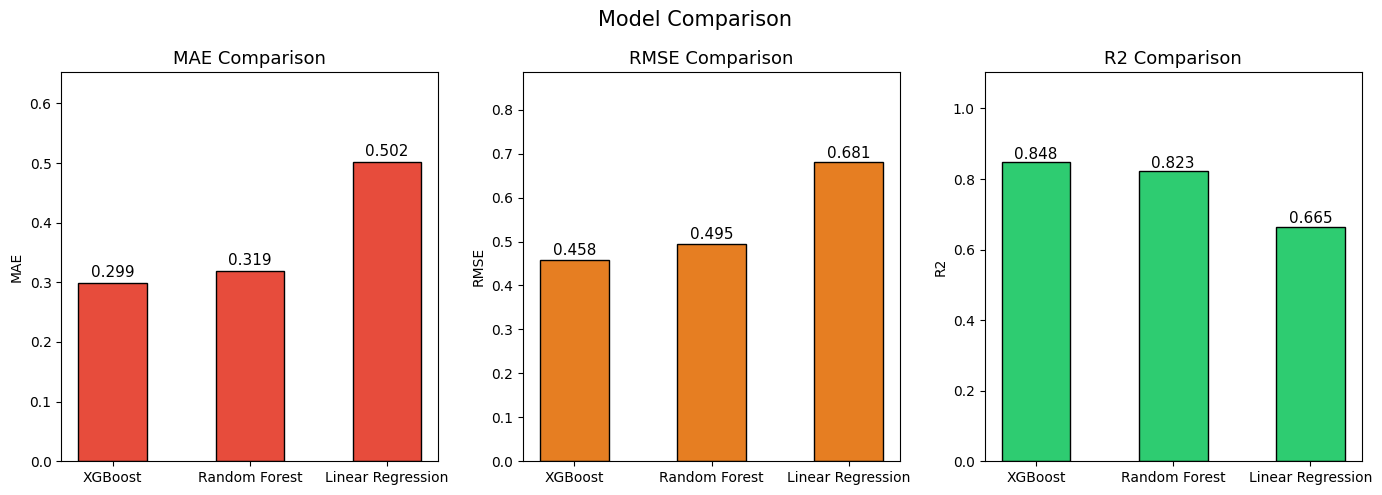

In [9]:
fig, axes = plt.subplots(1, 3, figsize = (14, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#e74c3c', '#e67e22', '#2ecc71']

for i, metric in enumerate(metrics):
    axes[i].bar(results['Model'], results[metric], color = colors[i], edgecolor = 'black', width = 0.5)
    axes[i].set_title(f"{metric} Comparison", fontsize = 13)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, results[metric].max() * 1.3)

    #Adds value label on top of bars
    for j, val in enumerate(results[metric]):
        axes[i].text(j, val + 0.01, f'{val:.3f}', ha = 'center', fontsize = 11)

plt.suptitle("Model Comparison", fontsize = 15)
plt.tight_layout()
plt.show()

In [10]:
os.makedirs('../model', exist_ok=True)

joblib.dump(xgb_model, '../model/house_price_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')

print("Best model (XGBoost) saved to model/house_price_model.pkl")
print("Scaler saved to model/scaler.pkl")

Best model (XGBoost) saved to model/house_price_model.pkl
Scaler saved to model/scaler.pkl
